# UCF-Crime Dataset — EDA (Google Colab)
Exploratory Data Analysis for the UCF-Crime violence subset.
**Categories:** Fighting, Shooting, Explosion, Robbery, Abuse, NormalVideos

In [10]:
# Run this first in a new cell
!cp /content/drive/MyDrive/... /content/ucf_crime_eda.ipynb  # skip if already in Colab

cp: cannot stat '/content/drive/MyDrive/...': No such file or directory


In [11]:
!ls /content/ucf_crime/Train
!ls /content/ucf_crime/Testx


Abuse  Explosion  Fighting  NormalVideos  Robbery  Shooting
ls: cannot access '/content/ucf_crime/Testx': No such file or directory


In [12]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────────
import os, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# ── Dataset root — change if yours is somewhere else ─────────────────────────
DATASET_ROOT = Path('/content/ucf_crime')
TRAIN_DIR    = DATASET_ROOT / 'Train'
TEST_DIR     = DATASET_ROOT / 'Test'

VIOLENCE_CATS = ['Abuse', 'Explosion', 'Fighting', 'Robbery', 'Shooting']
ALL_CATS      = VIOLENCE_CATS + ['NormalVideos']

print('Train exists:', TRAIN_DIR.exists())
print('Test exists :', TEST_DIR.exists())
print('Categories  :', sorted(os.listdir(TRAIN_DIR)))

Train exists: True
Test exists : True
Categories  : ['Abuse', 'Explosion', 'Fighting', 'NormalVideos', 'Robbery', 'Shooting']


## 1. Video Count per Category

In [16]:
import os
import pandas as pd

# These folders contain FRAMES not video files - count subfolders instead
records = []
for split, split_dir in [('Train', '/content/ucf_crime/Train'),
                          ('Test',  '/content/ucf_crime/Test')]:
    for cat in ['Abuse', 'Explosion', 'Fighting', 'Robbery', 'Shooting', 'NormalVideos']:
        path = f'{split_dir}/{cat}'
        if not os.path.exists(path):
            continue
        # Count video subfolders (each subfolder = 1 video)
        subdirs = [d for d in os.listdir(path) if os.path.isdir(f'{path}/{d}')]
        n_videos = len(subdirs) if subdirs else len(os.listdir(path))
        records.append({'split': split, 'category': cat, 'count': n_videos})

count_df = pd.DataFrame(records)
print(count_df.to_string(index=False))

split     category  count
Train        Abuse  19076
Train    Explosion  18753
Train     Fighting  24684
Train      Robbery  41493
Train     Shooting   7140
Train NormalVideos 947768
 Test        Abuse    297
 Test    Explosion   6510
 Test     Fighting   1231
 Test      Robbery    835
 Test     Shooting   7630
 Test NormalVideos  64952


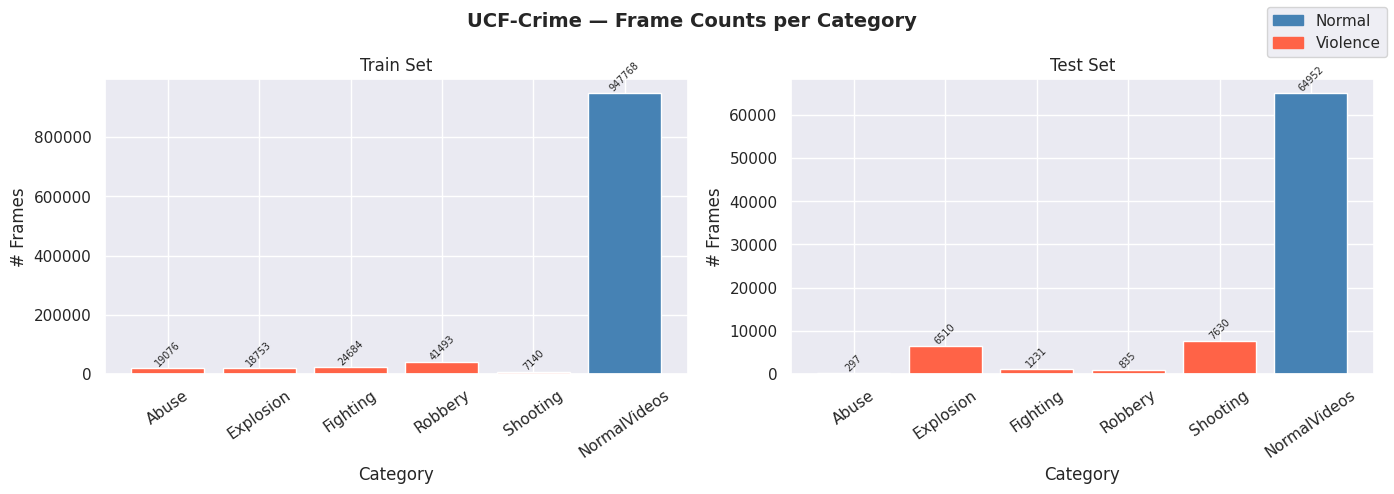

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('UCF-Crime — Frame Counts per Category', fontsize=14, fontweight='bold')

for ax, split in zip(axes, ['Train', 'Test']):
    sub = count_df[count_df['split'] == split]
    bars = ax.bar(sub['category'], sub['count'],
                  color=['steelblue' if c == 'NormalVideos' else 'tomato' for c in sub['category']],
                  edgecolor='white')
    ax.bar_label(bars, fmt='%d', fontsize=7, rotation=45)
    ax.set_title(f'{split} Set')
    ax.set_xlabel('Category')
    ax.set_ylabel('# Frames')
    ax.tick_params(axis='x', rotation=35)

fig.legend(handles=[mpatches.Patch(color='steelblue', label='Normal'),
                    mpatches.Patch(color='tomato', label='Violence')], loc='upper right')
plt.tight_layout()
plt.show()

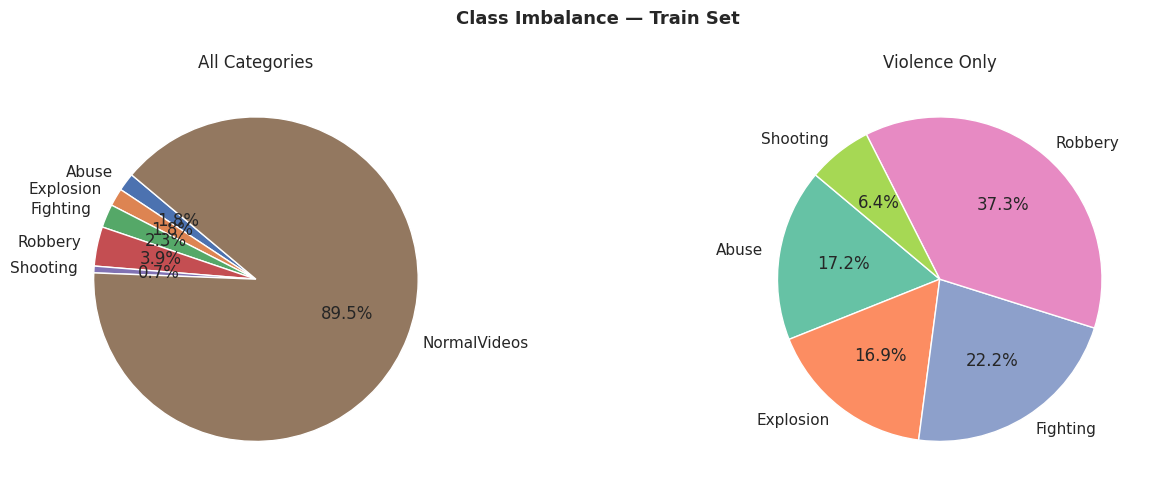

In [22]:
import seaborn as sns

VIOLENCE_CATS = ['Abuse', 'Explosion', 'Fighting', 'Robbery', 'Shooting']
train_counts = count_df[count_df['split'] == 'Train'].set_index('category')['count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance — Train Set', fontsize=13, fontweight='bold')

axes[0].pie(train_counts.values, labels=train_counts.index, autopct='%1.1f%%', startangle=140)
axes[0].set_title('All Categories')

viol = train_counts[VIOLENCE_CATS]
axes[1].pie(viol.values, labels=viol.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(VIOLENCE_CATS)))
axes[1].set_title('Violence Only')
plt.tight_layout()
plt.show()

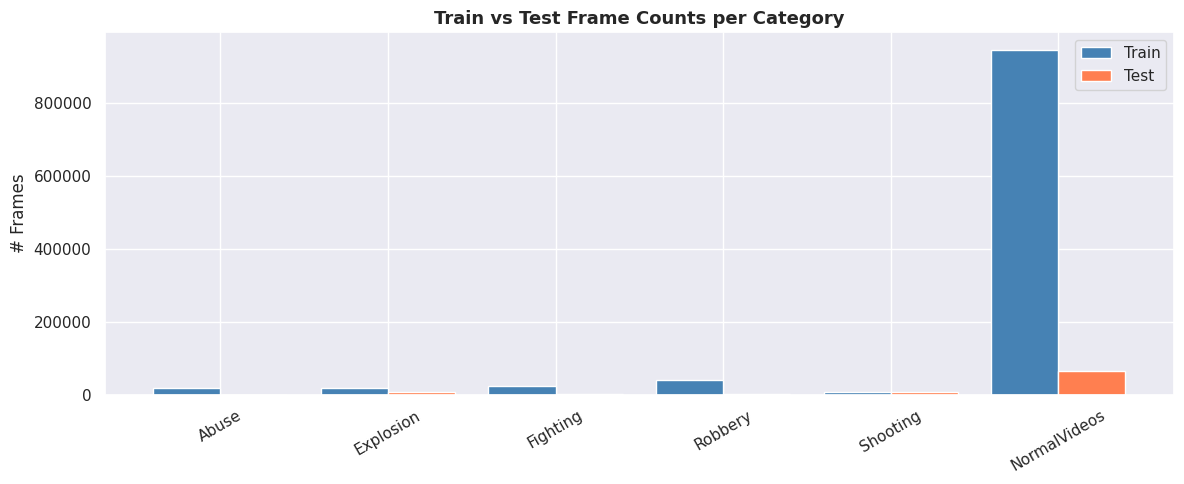

In [23]:
ALL_CATS = VIOLENCE_CATS + ['NormalVideos']
x = range(len(ALL_CATS))
train_vals = [count_df[(count_df['split']=='Train') & (count_df['category']==c)]['count'].values[0] for c in ALL_CATS]
test_vals  = [count_df[(count_df['split']=='Test')  & (count_df['category']==c)]['count'].values[0] for c in ALL_CATS]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - 0.2 for i in x], train_vals, width=0.4, label='Train', color='steelblue')
ax.bar([i + 0.2 for i in x], test_vals,  width=0.4, label='Test',  color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(ALL_CATS, rotation=30)
ax.set_title('Train vs Test Frame Counts per Category', fontsize=13, fontweight='bold')
ax.set_ylabel('# Frames')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Summary

In [24]:
total_viol = train_counts[VIOLENCE_CATS].sum()
total_norm = train_counts['NormalVideos']
print('='*45)
print(f'Train violence frames : {total_viol:,}')
print(f'Train normal frames   : {total_norm:,}')
print(f'Imbalance ratio       : 1:{total_norm/total_viol:.2f} (violence:normal)')
print('='*45)
print(count_df.to_string(index=False))

Train violence frames : 111,146
Train normal frames   : 947,768
Imbalance ratio       : 1:8.53 (violence:normal)
split     category  count
Train        Abuse  19076
Train    Explosion  18753
Train     Fighting  24684
Train      Robbery  41493
Train     Shooting   7140
Train NormalVideos 947768
 Test        Abuse    297
 Test    Explosion   6510
 Test     Fighting   1231
 Test      Robbery    835
 Test     Shooting   7630
 Test NormalVideos  64952
